# Ridge regularization for simple lr

In [44]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
import numpy as np
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import make_regression

X,y=make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1, #means only 1 feature is actually used to generate the target y
    noise=20,
    random_state=20)

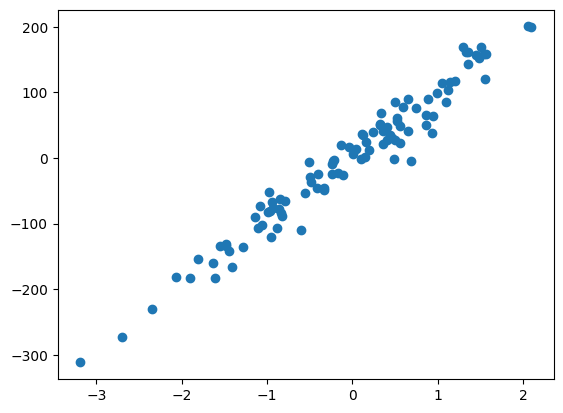

In [45]:
plt.scatter(X,y)

In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[96.23791062]
2.2912972569160335


In [50]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[88.54115158]
1.8716161631861947


In [104]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[51.48377864]
-0.14901079666253336


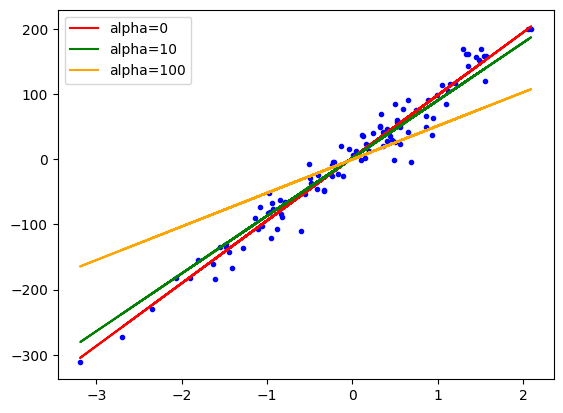

In [53]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha=0')
plt.plot(X,rr.predict(X),color='green',label='alpha=10')
plt.plot(X,rr1.predict(X),color='orange',label='alpha=100')
plt.legend()

## creating from scratch

In [105]:
class ScrRidge:
    def __init__(self,alpha=10):
        self.alpha=alpha
        self.m=None
        self.b=None
    def fit(self,X_train,y_train):
        num=0
        den=0

        for i in range(X_train.shape[0]):
            num = num + (y_train[i] - y_train.mean())*(X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean())*(X_train[i] - X_train.mean())
        
        self.m=num/(den+self.alpha)
        self.b=y_train.mean()-(self.m*X_train.mean())
        print(self.m,self.b)
    def predict(X_test):
        pass
        

In [106]:
reg = ScrRidge(alpha=100)

In [107]:
reg.fit(X,y)

[51.48377864] [-0.1490108]


# Ridge regularization for Multiple columns

In [109]:
from sklearn.datasets import load_diabetes

In [143]:
data= load_diabetes()

In [144]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [148]:
X=data.data
y=data.target

In [149]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [150]:
from sklearn.linear_model import Ridge

In [151]:
reg = Ridge(alpha=0.1,solver='cholesky')

In [152]:
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.5208421054129915

In [153]:
print(reg.coef_)
print(reg.intercept_)

[  31.03389163 -204.8305909   464.8963454   304.96414918  -95.76037039
  -87.52969228 -183.81809293  147.49794012  425.85392451  110.21559915]
152.07141290172817


In [154]:
class MeraRidge:
    
    def __init__(self,alpha=0.1):
        
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [155]:
reg = MeraRidge()
reg.fit(X_train,y_train)
y_pred = reg.predict(X_test)
print(r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

0.5208421054129914
[  31.03389163 -204.8305909   464.8963454   304.96414918  -95.76037039
  -87.52969228 -183.81809293  147.49794012  425.85392451  110.21559915]
152.07141290172822


# Using Gradient Desent 

In [156]:
from sklearn.linear_model import SGDRegressor

In [157]:
reg = SGDRegressor(penalty='l2',max_iter=500,eta0=0.1,learning_rate='constant',alpha=0.001)

In [158]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.4530908524755113
[  39.67404739 -126.95108833  376.93903427  255.01980872  -29.81977472
  -74.31705128 -183.78480725  128.46958039  321.09427726  134.83098394]
[137.12985582]


In [162]:
from sklearn.linear_model import Ridge

reg = Ridge(alpha=0.001, max_iter=500,solver='sparse_cg')

In [163]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.5201448363733796
[  24.01614157 -246.40604595  493.59285633  329.08832668 -852.76774004
  479.42466511  131.86683001  243.03291514  748.9646394    90.15507892]
152.12463295186845


In [166]:
 class MeraRidgeGD:   
    def __init__(self,epochs,learning_rate,alpha):
        
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        self.coef_ = np.ones(X_train.shape[1])
        self.intercept_ = 0
        thetha = np.insert(self.coef_,0,self.intercept_)
        
        X_train = np.insert(X_train,0,1,axis=1)
        
        for i in range(self.epochs):
            thetha_der = np.dot(X_train.T,X_train).dot(thetha) - np.dot(X_train.T,y_train) + self.alpha*thetha
            thetha = thetha - self.learning_rate*thetha_der
        
        self.coef_ = thetha[1:]
        self.intercept_ = thetha[0]
    
    def predict(self,X_test):
        
        return np.dot(X_test,self.coef_) + self.intercept_

In [167]:
reg = MeraRidgeGD(epochs=500,alpha=0.001,learning_rate=0.005)

In [168]:
reg.fit(X_train,y_train)

y_pred = reg.predict(X_test)
print("R2 score",r2_score(y_test,y_pred))
print(reg.coef_)
print(reg.intercept_)

R2 score 0.515430712996193
[  34.15325939 -186.67106566  467.12291202  305.9828481   -54.21986474
 -113.96322748 -209.37110173  140.75794314  397.61388652  140.49462069]
152.0822237478433


In [3]:
a=np.zeros(3)

In [2]:
import numpy as np


In [4]:
a

array([0., 0., 0.])